## Import Libraries

In [158]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.utils import resample

## Load Data

In [159]:
df = pd.read_excel("insurance.xlsx")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Group      40000 non-null  str  
 1   Seq nr     40000 non-null  int64
 2   age        40000 non-null  int64
 3   job        40000 non-null  str  
 4   marital    40000 non-null  str  
 5   education  40000 non-null  str  
 6   default    40000 non-null  str  
 7   balance    40000 non-null  int64
 8   housing    40000 non-null  str  
 9   loan       40000 non-null  str  
 10  contact    40000 non-null  str  
 11  day        40000 non-null  int64
 12  month      40000 non-null  str  
 13  duration   40000 non-null  int64
 14  campaign   40000 non-null  int64
 15  pdays      40000 non-null  int64
 16  previous   40000 non-null  int64
 17  poutcome   40000 non-null  str  
 18  y          40000 non-null  str  
dtypes: int64(8), str(11)
memory usage: 5.8 MB


In [160]:
df.head()

,Group,Seq nr,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,Training,1,30,management,married,tertiary,no,1119,no,no,cellular,6,aug,199,7,-1,0,unknown,no
1,Training,2,54,management,married,tertiary,no,-1415,yes,yes,cellular,17,nov,135,1,-1,0,unknown,no
2,Training,3,46,admin.,single,unknown,yes,0,no,no,unknown,23,may,378,2,-1,0,unknown,no
3,Training,4,33,management,married,tertiary,no,2213,no,no,cellular,18,feb,240,1,385,9,failure,no
4,Training,5,52,admin.,married,secondary,no,484,yes,no,unknown,6,may,128,1,-1,0,unknown,no


In [161]:
for col in df.columns:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== Group ===
Group
Training    36000
Test         4000
Name: count, dtype: int64

=== Seq nr ===
Seq nr
1        1
2        1
3        1
4        1
5        1
        ..
39996    1
39997    1
39998    1
39999    1
40000    1
Name: count, Length: 40000, dtype: int64

=== age ===
age
32    1857
31    1766
33    1740
34    1712
35    1661
      ... 
88       2
90       2
95       2
92       1
93       1
Name: count, Length: 76, dtype: int64

=== job ===
job
blue-collar      8607
management       8372
technician       6737
admin.           4582
services         3668
retired          1990
self-employed    1393
entrepreneur     1329
unemployed       1180
housemaid        1070
student           834
unknown           238
Name: count, dtype: int64

=== marital ===
marital
married     24073
single      11328
divorced     4599
Name: count, dtype: int64

=== education ===
education
secondary    20528
tertiary     11784
primary       6043
unknown       1645
Name: count, dtype: int64

=== default 

In [162]:
df.head()

,Group,Seq nr,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,Training,1,30,management,married,tertiary,no,1119,no,no,cellular,6,aug,199,7,-1,0,unknown,no
1,Training,2,54,management,married,tertiary,no,-1415,yes,yes,cellular,17,nov,135,1,-1,0,unknown,no
2,Training,3,46,admin.,single,unknown,yes,0,no,no,unknown,23,may,378,2,-1,0,unknown,no
3,Training,4,33,management,married,tertiary,no,2213,no,no,cellular,18,feb,240,1,385,9,failure,no
4,Training,5,52,admin.,married,secondary,no,484,yes,no,unknown,6,may,128,1,-1,0,unknown,no


## Preprocessing

In [163]:
cleaned_df = df

In [164]:
# Drop 'duration' column since it highly affects output target. Only known after call ends. Can cause data leakage
# (https://archive.ics.uci.edu/dataset/222/bank+marketing)

# cleaned_df = cleaned_df.drop(columns='duration')

In [165]:
# For 'pdays' -1 refers to never contacted
# Created another column indicating that then convert -1 to 0 in original column
# Reduced impact when scaling pdays

cleaned_df['pdays_was_contacted'] = (cleaned_df['pdays'] != -1).astype(int)
cleaned_df['pdays'] = cleaned_df['pdays'].replace(-1, 0)

In [166]:
# Encode binary columns as 0/1
binary_map = {
    "default": {"no": 0, "yes": 1},
    "housing": {"no": 0, "yes": 1},
    "loan": {"no": 0, "yes": 1},
    "y": {"no": 0, "yes": 1},
}

for col, mapping in binary_map.items():
    cleaned_df[col] = cleaned_df[col].map(mapping)

In [167]:
# day and month should be encoded using cyclic encoding to represent that 31 is close to 1 and Dec is close to Jan
nr_days = 31
nr_months = 12

cleaned_df['day_sin'] = np.sin(2* np.pi * cleaned_df['day'] / nr_days)
cleaned_df['day_cos'] = np.cos(2* np.pi * cleaned_df['day'] / nr_days)

months = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,
    "may": 5, "jun": 6, "jul": 7, "aug": 8,
    "sep": 9, "oct": 10, "nov": 11, "dec": 12,
}

cleaned_df['month'] = cleaned_df['month'].map(months)

cleaned_df['month_sin'] = np.sin(2* np.pi * cleaned_df['month'] / nr_months)
cleaned_df['month_cos'] = np.cos(2* np.pi * cleaned_df['month'] / nr_months)

cleaned_df = cleaned_df.drop(columns=['day', 'month'])

In [168]:
cleaned_df.head()

,Group,Seq nr,age,job,marital,education,default,balance,housing,loan,...,campaign,pdays,previous,poutcome,y,pdays_was_contacted,day_sin,day_cos,month_sin,month_cos
0,Training,1,30,management,married,tertiary,0,1119,0,0,...,7,0,0,unknown,0,0,0.937752,0.347305,-0.866025,-0.500000
1,Training,2,54,management,married,tertiary,0,-1415,1,1,...,1,0,0,unknown,0,0,-0.299363,-0.954139,-0.500000,0.866025
2,Training,3,46,admin.,single,unknown,1,0,0,0,...,2,0,0,unknown,0,0,-0.998717,-0.050649,0.500000,-0.866025
3,Training,4,33,management,married,tertiary,0,2213,0,0,...,1,385,9,failure,0,1,-0.485302,-0.874347,0.866025,0.500000
4,Training,5,52,admin.,married,secondary,0,484,1,0,...,1,0,0,unknown,0,0,0.937752,0.347305,0.500000,-0.866025


## Split Data

In [169]:
# Use 'Group' column to split data (already 90/10 split)
train_df = cleaned_df[cleaned_df["Group"] == 'Training']
test_df = cleaned_df[cleaned_df["Group"] == 'Test']

In [170]:
# Get X and y splits
X_cols = cleaned_df.columns.drop(['Group', 'Seq nr', 'y']).tolist()
y_cols = 'y'

## Make Model

In [171]:
def make_model(modelType='linear'):
    binary_cols = ["default", "housing", "loan", "pdays_was_contacted"]

    # Normalize numeric columns
    numeric_cols = [
        "age","balance","campaign","pdays","previous","day_sin","day_cos","month_sin","month_cos","duration"
    ]

    # One-hot encode categorical columns with few unique values and no order
    categorical_cols = [
        "job","marital","education","contact",'poutcome'
    ]

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_cols)
    ])
    
    if modelType == 'linear':
        model = LinearRegression()
    elif modelType == 'logistic':
        model = LogisticRegression()
    else:
        raise ValueError("modelTpye must be 'logistic' or 'linear'")

    return Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

## Run Bootstrap on Model

In [172]:
# Number of runs for bootstrap
iterations = 1000

In [173]:
# Linear Regression
linear_model = make_model('linear')
linear_intercepts = []

# Bootstrap
for run in range(iterations):
    # Resample data with replacement
    bootstrap_df = resample(train_df, replace=True, n_samples=len(train_df), random_state=run)

    X_train = bootstrap_df[X_cols]
    y_train = bootstrap_df[y_cols]

    linear_model.fit(X_train, y_train)

    linear_intercept = linear_model.named_steps["model"].intercept_
    linear_intercepts.append(linear_intercept)

linear_intercepts = np.array(linear_intercepts)

# Can you percentiles for bootstrapped data: 95% confidence interval is 2.5% percentile and 97.5% percentile
linear_lower, linear_upper = np.percentile(linear_intercepts, [2.5, 97.5])

In [174]:
# Logistic Regression
logistic_model = make_model('logistic')
logistic_intercepts = []

# Bootstrap
for run in range(iterations):
    # Resample data with replacement
    bootstrap_df = resample(train_df, replace=True, n_samples=len(train_df), random_state=run)

    X_train = bootstrap_df[X_cols]
    y_train = bootstrap_df[y_cols]

    logistic_model.fit(X_train, y_train)

    logistic_intercept = logistic_model.named_steps["model"].intercept_
    logistic_intercepts.append(logistic_intercept[0])

logistic_intercepts = np.array(logistic_intercepts)

# Can you percentiles for bootstrapped data: 95% confidence interval is 2.5% percentile and 97.5% percentile
logistic_lower, logistic_upper = np.percentile(logistic_intercepts, [2.5, 97.5])

## Visualisation

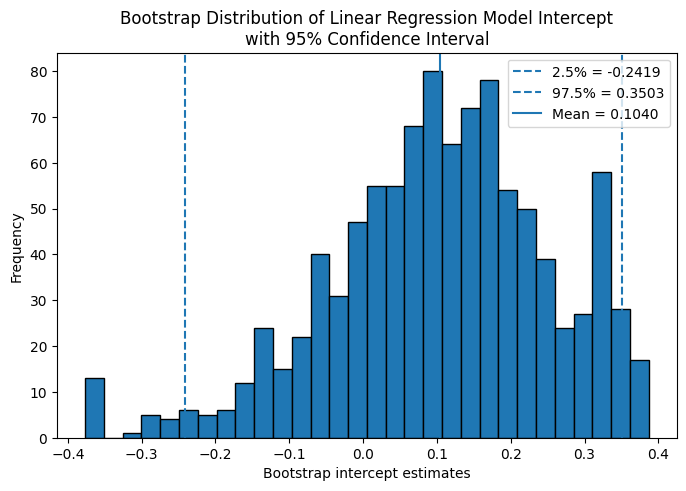

In [177]:
# Linear Regression

plt.figure(figsize=(8,5))
plt.hist(linear_intercepts, bins=30, edgecolor='black')
plt.axvline(linear_lower, linestyle='--', label=f'2.5% = {linear_lower:.4f}')
plt.axvline(linear_upper, linestyle='--', label=f'97.5% = {linear_upper:.4f}')
plt.axvline(np.mean(linear_intercepts), linestyle='-', label=f'Mean = {np.mean(linear_intercepts):.4f}')

plt.xlabel("Bootstrap intercept estimates")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Linear Regression Model Intercept\nwith 95% Confidence Interval")
plt.legend()
plt.show()

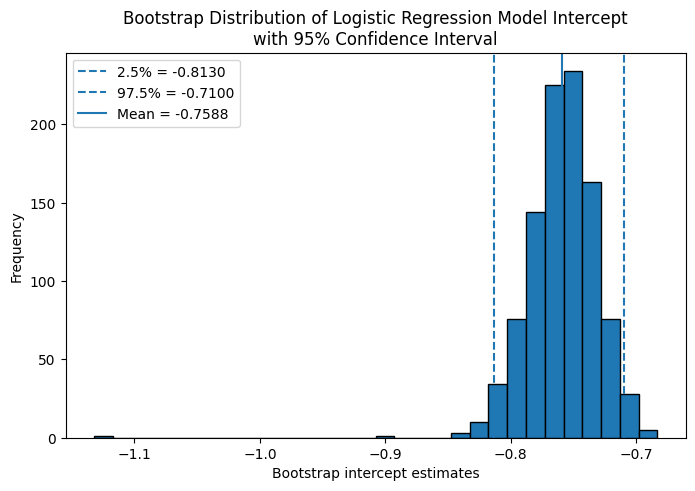

In [178]:
# Logistic Regression

plt.figure(figsize=(8,5))
plt.hist(logistic_intercepts, bins=30, edgecolor='black')
plt.axvline(logistic_lower, linestyle='--', label=f'2.5% = {logistic_lower:.4f}')
plt.axvline(logistic_upper, linestyle='--', label=f'97.5% = {logistic_upper:.4f}')
plt.axvline(np.mean(logistic_intercepts), linestyle='-', label=f'Mean = {np.mean(logistic_intercepts):.4f}')

plt.xlabel("Bootstrap intercept estimates")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Logistic Regression Model Intercept\nwith 95% Confidence Interval")
plt.legend()
plt.show()

## Hypothesis Testing

In [179]:
# Rule: Reject H0 if 0 not in Confidence interval, Fail to reject H0 if 0 in Confidence interval
def hypothesis_testing(lower_percentile, upper_percentile):
    if lower_percentile <= 0 and upper_percentile >= 0:
        return "Fail to reject H0: the intercept is not significantly different from 0."
    else:
        return "Reject H0: the intercept is significantly different from 0."

print("Linear model:", hypothesis_testing(linear_lower, linear_upper))
print("Logistic model:", hypothesis_testing(logistic_lower, logistic_upper))

Linear model: Fail to reject H0: the intercept is not significantly different from 0.
Logistic model: Reject H0: the intercept is significantly different from 0.
